## Train a simple convnet on the Fashion MNIST dataset

In this, we will see how to deal with image data and train a convnet for image classification task.

### Load the  `fashion_mnist`  dataset

** Use keras.datasets to load the dataset **

In [1]:
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

Using TensorFlow backend.


### Find no.of samples are there in training and test datasets

In [2]:
x_train.shape

(60000, 28, 28)

In [3]:
y_train.shape

(60000,)

In [4]:
x_test.shape

(10000, 28, 28)

In [5]:
y_test.shape

(10000,)

### Find dimensions of an image in the dataset

In [6]:
x_train[0].shape

(28, 28)

### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [7]:
from keras.utils import np_utils

In [8]:
y_train = np_utils.to_categorical(y_train, 10)
y_test = np_utils.to_categorical(y_test, 10)

### Normalize both the train and test image data from 0-255 to 0-1

In [9]:
x_train = x_train / 255.0

In [10]:
x_test = x_test / 255.0

### Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras

In [11]:
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1).astype('float32')

In [12]:
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1).astype('float32')

### Import the necessary layers from keras to build the model

In [18]:
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, Flatten, Reshape
from keras.layers import Convolution2D,Conv2D, MaxPooling2D
from keras.callbacks import EarlyStopping

### Build a model 

** with 2 Conv layers having `32 3*3 filters` in both convolutions with `relu activations` and `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. Now, using `categorical_crossentropy` loss with `adam` optimizer train the model with early stopping `patience=5` and no.of `epochs=10`. **

In [16]:
model = Sequential()
 # 1st Conv Layer
model.add(Convolution2D(32, 3, 3, input_shape=(28, 28, 1)))
model.add(Activation('relu'))

# 2nd Conv Layer
model.add(Convolution2D(32, 3, 3))
model.add(Activation('relu'))

# Fully Connected Layer
model.add(Flatten())
model.add(Dense(128))
model.add(Activation('relu'))

# Prediction Layer
model.add(Dense(10))
model.add(Activation('softmax'))

# Loss and Optimizer
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

/home/swaraj/apps/anaconda/lib/python3.6/site-packages/ipykernel_launcher.py:3: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(32, (3, 3), input_shape=(28, 28, 1...)`
  This is separate from the ipykernel package so we can avoid doing imports until
/home/swaraj/apps/anaconda/lib/python3.6/site-packages/ipykernel_launcher.py:7: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(32, (3, 3))`
  import sys


In [19]:
# Train the model2
early_stopping = EarlyStopping(monitor='val_acc', patience=5, verbose=1, mode='auto')
callback_list = [early_stopping]
model.fit(x_train, y_train, batch_size=5000, nb_epoch=10, validation_split=0.25, callbacks=callback_list)

/home/swaraj/apps/anaconda/lib/python3.6/site-packages/ipykernel_launcher.py:4: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.
  after removing the cwd from sys.path.


Train on 45000 samples, validate on 15000 samples
Epoch 1/10
45000/45000 [==============================] - 76s 2ms/step - loss: 1.2693 - acc: 0.5641 - val_loss: 0.8800 - val_acc: 0.7160
Epoch 2/10
45000/45000 [==============================] - 80s 2ms/step - loss: 0.7462 - acc: 0.7483 - val_loss: 0.5933 - val_acc: 0.7851
Epoch 3/10
45000/45000 [==============================] - 78s 2ms/step - loss: 0.5769 - acc: 0.7973 - val_loss: 0.5316 - val_acc: 0.8119
Epoch 4/10
45000/45000 [==============================] - 78s 2ms/step - loss: 0.5028 - acc: 0.8238 - val_loss: 0.4778 - val_acc: 0.8277
Epoch 5/10
45000/45000 [==============================] - 79s 2ms/step - loss: 0.4539 - acc: 0.8399 - val_loss: 0.4528 - val_acc: 0.8377
Epoch 6/10
45000/45000 [==============================] - 84s 2ms/step - loss: 0.4188 - acc: 0.8542 - val_loss: 0.4209 - val_acc: 0.8501
Epoch 7/10
45000/45000 [==============================] - 82s 2ms/step - loss: 0.3930 - acc: 0.8636 - val_loss: 0.4013 - val_acc

### Now, to the above model add `max` pooling layer of `filter size 2x2` and `dropout` layer with `p=0.25` after the 2 conv layers and run the model

In [22]:
model2 = Sequential()
 # 1st Conv Layer
model2.add(Convolution2D(32, 3, 3, input_shape=(28, 28, 1)))
model2.add(Activation('relu'))

#MaxPooling Layer
model2.add(MaxPooling2D(pool_size=(2,2)))

#Added dropout as mentioned
model2.add(Dropout(0.25))

# 2nd Conv Layer
model2.add(Convolution2D(32, 3, 3))
model2.add(Activation('relu'))

#Max Pooling layer
model2.add(MaxPooling2D(pool_size=(2,2)))
model2.add(Dropout(0.25))

# Fully Connected Layer
model2.add(Flatten())
model2.add(Dense(128))
model2.add(Activation('relu'))

# Prediction Layer
model2.add(Dense(10))
model2.add(Activation('softmax'))

# Loss and Optimizer
model2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    
early_stopping = EarlyStopping(monitor='val_acc', patience=5, verbose=1, mode='auto')
callback_list = [early_stopping]# [stats, early_stopping]

model2.fit(x_train, y_train, batch_size=5000, nb_epoch=10, validation_split=0.25, callbacks=callback_list)
   

/home/swaraj/apps/anaconda/lib/python3.6/site-packages/ipykernel_launcher.py:3: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(32, (3, 3), input_shape=(28, 28, 1...)`
  This is separate from the ipykernel package so we can avoid doing imports until
/home/swaraj/apps/anaconda/lib/python3.6/site-packages/ipykernel_launcher.py:13: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(32, (3, 3))`
  del sys.path[0]
/home/swaraj/apps/anaconda/lib/python3.6/site-packages/ipykernel_launcher.py:35: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.


Train on 45000 samples, validate on 15000 samples
Epoch 1/10
45000/45000 [==============================] - 32s 710us/step - loss: 2.1238 - acc: 0.2899 - val_loss: 1.7970 - val_acc: 0.5479
Epoch 2/10
45000/45000 [==============================] - 32s 710us/step - loss: 1.3831 - acc: 0.5554 - val_loss: 0.9972 - val_acc: 0.6651
Epoch 3/10
45000/45000 [==============================] - 34s 745us/step - loss: 0.9390 - acc: 0.6532 - val_loss: 0.8076 - val_acc: 0.7107
Epoch 4/10
45000/45000 [==============================] - 31s 698us/step - loss: 0.8238 - acc: 0.7000 - val_loss: 0.7197 - val_acc: 0.7323
Epoch 5/10
45000/45000 [==============================] - 36s 809us/step - loss: 0.7390 - acc: 0.7229 - val_loss: 0.6795 - val_acc: 0.7512
Epoch 6/10
45000/45000 [==============================] - 35s 787us/step - loss: 0.6890 - acc: 0.7441 - val_loss: 0.6284 - val_acc: 0.7673
Epoch 7/10
45000/45000 [==============================] - 34s 765us/step - loss: 0.6492 - acc: 0.7558 - val_loss: 0.

### Now, to the above model, lets add Data Augmentation 

### Import the ImageDataGenrator from keras and fit the training images

In [23]:
from keras.preprocessing.image import ImageDataGenerator

In [24]:
# This will do preprocessing and realtime data augmentation:
datagen = ImageDataGenerator(
    featurewise_center=False,  # set input mean to 0 over the dataset
    samplewise_center=False,  # set each sample mean to 0
    featurewise_std_normalization=False,  # divide inputs by std of the dataset
    samplewise_std_normalization=False,  # divide each input by its std
    zca_whitening=False,  # apply ZCA whitening
    rotation_range=50,  # randomly rotate images in the range (degrees, 0 to 180)
    width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
    height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
    horizontal_flip=False,  # randomly flip images
    vertical_flip=False)  # randomly flip images

# Prepare the generator
datagen.fit(x_train)

#### Showing 5 versions of the first image in training dataset using image datagenerator.flow()

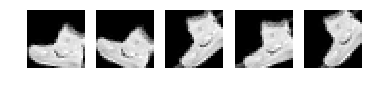

In [26]:
from matplotlib import pyplot as plt
gen = datagen.flow(x_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()

### Run the above model using fit_generator()

In [27]:
model2.fit_generator(datagen.flow(x_train, y_train), nb_epoch=10,validation_data=(x_test, y_test), callbacks=callback_list, verbose=True)

Epoch 1/10
   3/1875 [..............................] - ETA: 1:18 - loss: 1.8910 - acc: 0.3958

/home/swaraj/apps/anaconda/lib/python3.6/site-packages/ipykernel_launcher.py:1: UserWarning: The semantics of the Keras 2 argument `steps_per_epoch` is not the same as the Keras 1 argument `samples_per_epoch`. `steps_per_epoch` is the number of batches to draw from the generator at each epoch. Basically steps_per_epoch = samples_per_epoch/batch_size. Similarly `nb_val_samples`->`validation_steps` and `val_samples`->`steps` arguments have changed. Update your method calls accordingly.
  """Entry point for launching an IPython kernel.
/home/swaraj/apps/anaconda/lib/python3.6/site-packages/ipykernel_launcher.py:1: UserWarning: Update your `fit_generator` call to the Keras 2 API: `fit_generator(<keras_pre..., validation_data=(array([[[..., callbacks=[<keras.ca..., verbose=True, epochs=10)`
  """Entry point for launching an IPython kernel.


1875/1875 [==============================] - 63s 34ms/step - loss: 0.8764 - acc: 0.6770 - val_loss: 0.6081 - val_acc: 0.7706
Epoch 2/10
1875/1875 [==============================] - 64s 34ms/step - loss: 0.6617 - acc: 0.7513 - val_loss: 0.5419 - val_acc: 0.8022
Epoch 3/10
1875/1875 [==============================] - 66s 35ms/step - loss: 0.5972 - acc: 0.7755 - val_loss: 0.4779 - val_acc: 0.8236
Epoch 4/10
1875/1875 [==============================] - 69s 37ms/step - loss: 0.5545 - acc: 0.7932 - val_loss: 0.4882 - val_acc: 0.8131
Epoch 5/10
1875/1875 [==============================] - 71s 38ms/step - loss: 0.5333 - acc: 0.8022 - val_loss: 0.4356 - val_acc: 0.8373
Epoch 6/10
1875/1875 [==============================] - 68s 36ms/step - loss: 0.5124 - acc: 0.8080 - val_loss: 0.4206 - val_acc: 0.8495
Epoch 7/10
1875/1875 [==============================] - 69s 37ms/step - loss: 0.5010 - acc: 0.8135 - val_loss: 0.4176 - val_acc: 0.8515
Epoch 8/10
1875/1875 [==============================] - 74s

###  Report the final train and validation accuracy

In [29]:
#First Model evaluate on train set
model.evaluate(x_train, y_train)

60000/60000 [==============================] - 41s 681us/step


[0.3355833323061466, 0.8815]

In [31]:
#First Model evaluate on train set
model.evaluate(x_test, y_test)

10000/10000 [==============================] - 7s 680us/step


[0.37012835896015167, 0.8678]

In [28]:
#Second Model evaluate on test set
model2.evaluate(x_train, y_train)

60000/60000 [==============================] - 17s 278us/step


[0.36563819582859675, 0.864]

In [32]:
#Second Model evaluate on test set
model2.evaluate(x_test, y_test)

10000/10000 [==============================] - 3s 267us/step


[0.3976812423467636, 0.8581]

## **DATA AUGMENTATION ON CIFAR10 DATASET**

One of the best ways to improve the performance of a Deep Learning model is to add more data to the training set. Aside from gathering more instances from the wild that are representative of the distinction task, we want to develop a set of methods that enhance the data we already have. There are many ways to augment existing datasets and produce more robust models. In the image domain, these are done to utilize the full power of the convolutional neural network, which is able to capture translational invariance. This translational invariance is what makes image recognition such a difficult task in the first place. You want the dataset to be representative of the many different positions, angles, lightings, and miscellaneous distortions that are of interest to the vision task.

### **Import neessary libraries for data augmentation**

In [37]:
from keras.datasets import cifar10
from keras.models import Model
from keras.layers import Input

### **Load CIFAR10 dataset**

In [39]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

### **Create a data_gen funtion to genererator with image rotation,shifting image horizontally and vertically with random flip horizontally.**

In [41]:
batch_size = 32 # in each iteration, we consider 32 training examples at once
num_epochs = 2 # we iterate 20 times over the entire training set
kernel_size = 3 # we will use 3x3 kernels throughout
pool_size = 2 # we will use 2x2 pooling throughout
conv_depth_1 = 32 # we will initially have 32 kernels per conv. layer...
conv_depth_2 = 64 # ...switching to 64 after the first pooling layer
drop_prob_1 = 0.25 # dropout after pooling with probability 0.25
drop_prob_2 = 0.5 # dropout in the FC layer with probability 0.5
hidden_size = 512 # the FC layer will have 512 neurons

num_train, depth, height, width = x_train.shape
X_train = x_train.astype('float32') 
X_test = x_test.astype('float32')
X_train /= np.max(X_train) # Normalise data to [0, 1] range
X_test /= np.max(X_train) # Normalise data to [0, 1] range

Y_train = np_utils.to_categorical(y_train, 10) # One-hot encode the labels
Y_test = np_utils.to_categorical(y_test, 10) # One-hot encode the labels

inp = Input(shape=(depth, height, width)) # N.B. depth goes first in Keras!
# Conv [32] -> Conv [32] -> Pool (with dropout on the pooling layer)
conv_1 = Convolution2D(conv_depth_1, kernel_size, kernel_size, border_mode='same', activation='relu')(inp)
conv_2 = Convolution2D(conv_depth_1, kernel_size, kernel_size, border_mode='same', activation='relu')(conv_1)
pool_1 = MaxPooling2D(pool_size=(pool_size, pool_size))(conv_2)
drop_1 = Dropout(drop_prob_1)(pool_1)
# Conv [64] -> Conv [64] -> Pool (with dropout on the pooling layer)
conv_3 = Convolution2D(conv_depth_2, kernel_size, kernel_size, border_mode='same', activation='relu')(drop_1)
conv_4 = Convolution2D(conv_depth_2, kernel_size, kernel_size, border_mode='same', activation='relu')(conv_3)
pool_2 = MaxPooling2D(pool_size=(pool_size, pool_size))(conv_4)
drop_2 = Dropout(drop_prob_1)(pool_2)
# Now flatten to 1D, apply FC -> ReLU (with dropout) -> softmax
flat = Flatten()(drop_2)
hidden = Dense(hidden_size, activation='relu')(flat)
drop_3 = Dropout(drop_prob_2)(hidden)
out = Dense(10, activation='softmax')(drop_3)

model3 = Model(input=inp, output=out) # To define a model2, just specify its input and output layers

model3.compile(loss='categorical_crossentropy', # using the cross-entropy loss function
              optimizer='adam', # using the Adam optimiser
              metrics=['accuracy']) # reporting the accuracy

/home/swaraj/apps/anaconda/lib/python3.6/site-packages/ipykernel_launcher.py:22: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(32, (3, 3), activation="relu", padding="same")`
/home/swaraj/apps/anaconda/lib/python3.6/site-packages/ipykernel_launcher.py:23: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(32, (3, 3), activation="relu", padding="same")`
/home/swaraj/apps/anaconda/lib/python3.6/site-packages/ipykernel_launcher.py:27: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(64, (3, 3), activation="relu", padding="same")`
/home/swaraj/apps/anaconda/lib/python3.6/site-packages/ipykernel_launcher.py:28: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(64, (3, 3), activation="relu", padding="same")`
/home/swaraj/apps/anaconda/lib/python3.6/site-packages/ipykernel_launcher.py:37: UserWarning: Update your `Model` call to the Keras 2 API: `Model(inputs=Tensor("in..., outputs=Tensor("de...)`


### **Prepare/fit the generator.**

In [46]:
model3.fit_generator(datagen.flow(X_train, Y_train, # Train the model2 using the training set...
          batch_size=batch_size), nb_epoch=10,
          verbose=1,callbacks=callback_list, validation_data=(X_test, Y_test)) 

/home/swaraj/apps/anaconda/lib/python3.6/site-packages/ipykernel_launcher.py:3: UserWarning: The semantics of the Keras 2 argument `steps_per_epoch` is not the same as the Keras 1 argument `samples_per_epoch`. `steps_per_epoch` is the number of batches to draw from the generator at each epoch. Basically steps_per_epoch = samples_per_epoch/batch_size. Similarly `nb_val_samples`->`validation_steps` and `val_samples`->`steps` arguments have changed. Update your method calls accordingly.
  This is separate from the ipykernel package so we can avoid doing imports until
/home/swaraj/apps/anaconda/lib/python3.6/site-packages/ipykernel_launcher.py:3: UserWarning: Update your `fit_generator` call to the Keras 2 API: `fit_generator(<keras_pre..., verbose=1, callbacks=[<keras.ca..., validation_data=(array([[[..., epochs=10)`
  This is separate from the ipykernel package so we can avoid doing imports until


Epoch 1/10
1563/1563 [==============================] - 357s 229ms/step - loss: 1.7659 - acc: 0.3500 - val_loss: 10.9163 - val_acc: 0.3106
Epoch 2/10
1563/1563 [==============================] - 361s 231ms/step - loss: 1.4785 - acc: 0.4655 - val_loss: 10.7827 - val_acc: 0.3210
Epoch 3/10
1563/1563 [==============================] - 365s 234ms/step - loss: 1.3570 - acc: 0.5131 - val_loss: 9.8776 - val_acc: 0.3756
Epoch 4/10
1563/1563 [==============================] - 434s 278ms/step - loss: 1.2979 - acc: 0.5364 - val_loss: 10.7367 - val_acc: 0.3275
Epoch 5/10
1563/1563 [==============================] - 468s 299ms/step - loss: 1.2412 - acc: 0.5577 - val_loss: 9.5907 - val_acc: 0.3954
Epoch 6/10
1563/1563 [==============================] - 495s 317ms/step - loss: 1.2043 - acc: 0.5721 - val_loss: 10.6356 - val_acc: 0.3340
Epoch 7/10
1563/1563 [==============================] - 556s 356ms/step - loss: 1.1740 - acc: 0.5829 - val_loss: 10.5533 - val_acc: 0.3356
Epoch 8/10
1563/1563 [=======

### **Generate 5 images for 1 of the image of CIFAR10 train dataset.**